In [1]:
# ==================================================================================
# Carrera de Ingeniería de Sistemas
# Universidad Privada Franz Tamayo - UNIFRANZ
# ----------------------------------------------------------------------------------
#                       Asignatura: MINERIA DE DATOS
# ----------------------------------------------------------------------------------
#   Proyecto: EduAnalytics - Patrones de uso de IA generativa y riesgo de burnout
#   Integrantes: Milenka Chuquimia, Edson Tito, Carlos Valverde, Álvaro del Carpio,
#                Marcelo Escobar - Septiembre 2026
# ==================================================================================
#                TEMA: REGRESIÓN LOGÍSTICA (Hito 3.1 - Primera iteración)
# ==================================================================================


# 1. LIBRERIAS Y FUNCIONES

In [2]:
# Cargamos Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 2. PARAMETROS

# 3. Datos

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# cargamos datos
# Nota: el dataset publicado en el repo usa ';' como separador (exportación regional/es),
# no ',' -- si se usa el separador por defecto, pandas arma una sola columna con todo el texto.
edu_df = pd.read_csv('dataset/ai_student_impact_dataset (1).csv', sep=';')

print(edu_df.shape)
edu_df.head(2)

(50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low


# 4. PROCESO

## 4.1. ENTENDIMIENTO Y PREPARACIÓN DE DATOS

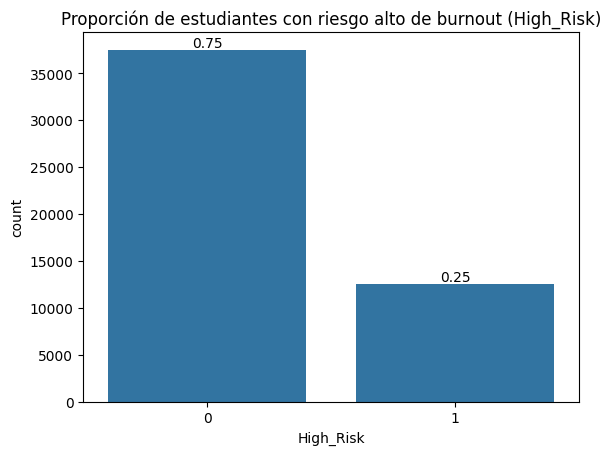

In [5]:
# variable objetivo del negocio: Burnout_Risk_Level (Low / Medium / High)
# para regresión logística binaria construimos High_Risk = 1 si el estudiante
# está clasificado como riesgo 'High', 0 en caso contrario.
edu_df['High_Risk'] = (edu_df['Burnout_Risk_Level'] == 'High').astype(int)

ax = sns.countplot(x='High_Risk', data=edu_df)
total = float(len(edu_df))
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 300,
            '{:1.2f}'.format(height/total),
            ha="center")
plt.title('Proporción de estudiantes con riesgo alto de burnout (High_Risk)')
plt.show()

Métrica principal: **24.97% de los estudiantes están clasificados con riesgo alto de burnout** (KPI de negocio ya definido en la Fase 1 / EDA del proyecto). Esta es la proporción que `High_Risk = 1` debe reflejar.

In [6]:
# una copia a los datos
df = edu_df.copy()

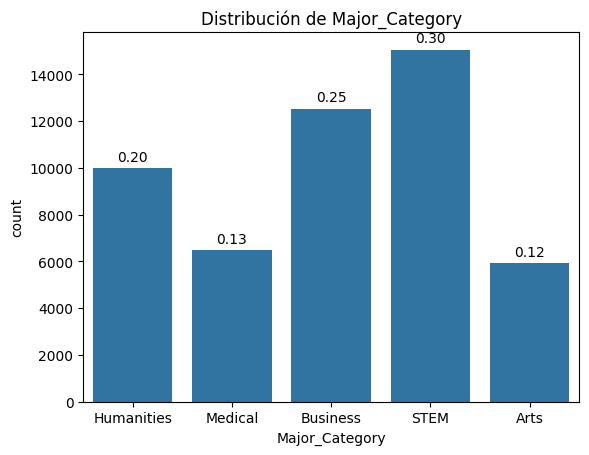

In [7]:
# grafico de barras de la variable "Major_Category" en el data frame df
ax = sns.countplot(x='Major_Category', data=df)
total = float(len(df))
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 300,
            '{:1.2f}'.format(height/total),
            ha="center")
plt.title('Distribución de Major_Category')
plt.show()

In [8]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'High_Risk'],
      dtype='str')

In [9]:
df.head(2)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,High_Risk
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,1
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,0


In [10]:
df['Institutional_Policy'].value_counts()

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [11]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,High_Risk
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125,0.249740
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626,0.432867
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000,0.000000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000,0.000000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000,0.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000,0.000000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000,1.000000


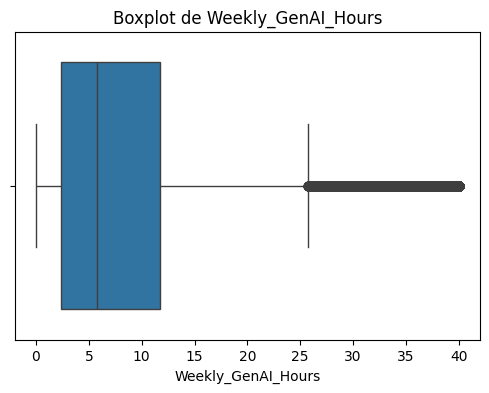

In [12]:
# Boxplot de la variable Weekly_GenAI_Hours (candidata a explicativa, con outliers ya
# identificados y NO eliminados en el EDA previo -- pueden representar comportamientos
# de uso intensivo que son justamente el foco del análisis)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Weekly_GenAI_Hours'])
plt.title('Boxplot de Weekly_GenAI_Hours')
plt.show()

In [13]:
# Convertimos variables categoricas a variables dummy
df = pd.get_dummies(df, columns=['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
                                  'Prompt_Engineering_Skill', 'Institutional_Policy'])
print(df.shape)
df.head(2)

(50000, 33)


,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,High_Risk,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,100001,2.418,23.31,1,True,8.13,5,6,2.393,86.44,High,1,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False
1,100002,3.821,1.12,5,False,16.65,3,9,3.696,69.39,Low,0,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False


In [14]:
# Convertimos a entero todas las columnas booleanas (Paid_Subscription y las dummies)
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

print(df.shape)
df.head(2)

(50000, 33)


,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,High_Risk,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,100001,2.418,23.31,1,1,8.13,5,6,2.393,86.44,High,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0
1,100002,3.821,1.12,5,0,16.65,3,9,3.696,69.39,Low,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0


## 4.2. Modelo

In [15]:
df.columns

Index(['Student_ID', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
       'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level',
       'High_Risk', 'Major_Category_Arts', 'Major_Category_Business',
       'Major_Category_Humanities', 'Major_Category_Medical',
       'Major_Category_STEM', 'Year_of_Study_Freshman',
       'Year_of_Study_Graduate', 'Year_of_Study_Junior',
       'Year_of_Study_Senior', 'Year_of_Study_Sophomore',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading',
       'Prompt_Engineering_Skill_Advanced',
       'Prompt_Engineering_Skill_Beginner',
       'Prompt_Engineering_Skill_Intermediate',
       'Institutional_Policy_Actively_Encouraged',
      

In [16]:
df.High_Risk.unique()

array([1, 0])

In [17]:
# seleccionamos variables explicativas y variable dependiente
# primera iteración: las dos variables con mayor asociación encontradas en el EDA
# (Weekly_GenAI_Hours <-> Perceived_AI_Dependency, r = 0.665; y el grupo High usa en
# promedio 15.22 h/semana frente a 4.64 h/semana del grupo Low)
X = df[['Weekly_GenAI_Hours', 'Perceived_AI_Dependency']]
#     ,'Traditional_Study_Hours','Anxiety_Level_During_Exams','Skill_Retention_Score']]
y = df['High_Risk']  # target variable

In [18]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

In [19]:
# tamaño de datos de entrenamiento
print('tamaño train', X_train.shape)
print('tamaño de test', X_test.shape)

tamaño train (40000, 2)
tamaño de test (10000, 2)


In [20]:
# Ajusta el modelo de regresión logística
modelo_logit = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.577718
         Iterations 5


## 4.3. Evaluación

### 4.3.1. Resultados del Modelo

In [21]:
# Muestra un resumen del modelo
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:              High_Risk   No. Observations:                40000
Model:                          Logit   Df Residuals:                    39998
Method:                           MLE   Df Model:                            1
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                -0.03227
Time:                        20:28:14   Log-Likelihood:                -23109.
converged:                       True   LL-Null:                       -22386.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Weekly_GenAI_Hours          0.1347      0.002     67.153      0.000       0.131       0.139
Perceived_AI_Dependency    -0.5271      0.006    -82.373      0.000      -0.540      -0.515


In [22]:
# prediccion
y_pred_train = modelo_logit.predict(X_train)
y_pred_train.head(20)

1114     0.333150
42946    0.391519
49921    0.870666
3305     0.811410
1733     0.188462
17166    0.462266
7781     0.232167
33879    0.399269
738      0.315047
18595    0.300377
20164    0.195760
35280    0.259331
18111    0.383530
2989     0.555163
10796    0.332552
12418    0.421395
27174    0.193649
34511    0.094334
22615    0.354741
7208     0.464764
dtype: float64

In [23]:
# Calcula la exactitud del modelo en el entrenamiento
# y_train: valores verdadaderos
# y_pred: valores predichos
exactitud_train = accuracy_score(y_train, (y_pred_train>0.5).astype(int))
print("exactitud del modelo:", exactitud_train)

exactitud del modelo: 0.728025


### Principales métricas de clasificación desde la matriz de confusión

La **matriz de confusión** resume los resultados de un modelo de clasificación comparando las predicciones con los valores reales. Sus componentes son:

- **TP (True Positives)**: casos positivos correctamente clasificados.  
- **TN (True Negatives)**: casos negativos correctamente clasificados.  
- **FP (False Positives)**: casos negativos mal clasificados como positivos.  
- **FN (False Negatives)**: casos positivos mal clasificados como negativos.  

A partir de estos valores se derivan las métricas:

- **Exactitud (Accuracy)**: proporción de predicciones correctas.  
  $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

- **Precisión (Precision)**: de los casos predichos como positivos, cuántos realmente lo son.  
  $$\text{Precision} = \frac{TP}{TP + FP}$$

- **Sensibilidad o Recall**: de los casos positivos reales, cuántos fueron detectados.  
  $$\text{Recall} = \frac{TP}{TP + FN}$$

- **F1-Score**: media armónica entre precisión y recall, útil cuando hay desbalance de clases.  
  $$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [24]:
# Matriz de confusión con el umbral estándar (0.5)
print("Matriz de confusión (umbral 0.5):\n", confusion_matrix(y_train, y_pred_train > 0.5))

Matriz de confusión (umbral 0.5):
 [[25823  4274]
 [ 6605  3298]]


In [25]:
#                          modelo         modelo
#                        No High_Risk   | High_Risk
# Valor Real | No High_Risk   TN(bien)       FP(mal)
# Valor Real |    High_Risk   FN(mal)        TP(bien)
#
# Con umbral 0.5 el modelo tiende a predecir casi siempre "No High_Risk" porque
# solo ~25% de los estudiantes son High_Risk -> conviene revisar un umbral más bajo,
# cercano a la proporción base del KPI (0.25), para no perder de vista la clase minoritaria.
print("Matriz de confusión (umbral 0.25, ~ proporción base del KPI):\n",
      confusion_matrix(y_train, y_pred_train > 0.25))

Matriz de confusión (umbral 0.25, ~ proporción base del KPI):
 [[10740 19357]
 [ 2518  7385]]


### 4.3.2. Predicción - Prueba

In [26]:
# Realiza predicciones en el conjunto de datos de prueba
y_pred = modelo_logit.predict(X_test)
y_pred.head(10)

17034    0.185784
16126    0.282584
47636    0.189685
29950    0.266112
33155    0.310395
34274    0.724645
10744    0.131530
37358    0.853221
27261    0.288628
27139    0.214758
dtype: float64

In [27]:
exactitud_test = accuracy_score(y_test, (y_pred>0.5).astype(int))
print("Exactitud del modelo (test, umbral 0.5):", exactitud_test)

Exactitud del modelo (test, umbral 0.5): 0.7324


1. **Métrica y valor**: % de estudiantes con riesgo alto de burnout = **24.97%** (línea base del KPI de negocio, ya definida en la Fase 1/EDA).
2. **Variable que calcula la métrica**: `Burnout_Risk_Level` (categórica: Low / Medium / High).
3. **Target definido**: `High_Risk` = 1 si `Burnout_Risk_Level == 'High'`, 0 en caso contrario — directamente ligado al KPI principal.
4. **Variables explicativas de esta primera iteración**: `Weekly_GenAI_Hours` y `Perceived_AI_Dependency`, las dos con mayor asociación entre sí (r = 0.665) y con la mayor diferencia observada entre los grupos Low y High en el EDA. Las variables categóricas ya quedaron codificadas como dummy en `df` para iteraciones siguientes.
5. **Partición de datos**: 80% train / 20% test, `random_state=777`.
6. **Modelo entrenado**: regresión logística (`statsmodels.Logit`) sin intercepto explícito, igual que el ejemplo de referencia.
7. **Evaluación en train**: exactitud ≈ **0.728**.
8. **Evaluación en test**: exactitud ≈ **0.732** (consistente con train, sin señales fuertes de sobreajuste).
9. **Resultado de la primera iteración y hallazgo a corregir**: el modelo logra ~73% de exactitud, pero **el coeficiente de `Perceived_AI_Dependency` sale negativo** (-0.53), lo cual contradice lo observado en el EDA (a mayor dependencia percibida, mayor proporción de riesgo `High`). Esto es un artefacto típico de **no incluir intercepto** combinado con la **colinealidad entre las dos variables** (r = 0.665 entre ellas): el modelo compensa una variable con la otra en vez de estimar el efecto real de cada una. El Pseudo R² también sale negativo (-0.032), reforzando que el ajuste sin intercepto no es confiable todavía. Con el umbral 0.5 el modelo además recupera pocos casos `High_Risk` reales (recall bajo) por el desbalance de clases (~25% positivos); bajar el umbral a ~0.25 recupera más positivos a costa de más falsos positivos. **Próxima iteración:** agregar `sm.add_constant` (o usar `LogisticRegression` de sklearn, que sí ajusta intercepto por defecto), revisar VIF por colinealidad entre `Weekly_GenAI_Hours` y `Perceived_AI_Dependency`, sumar variables categóricas ya codificadas (`Institutional_Policy`, `Primary_Use_Case`, etc.) y comparar F1-Score además de exactitud.